In [2]:
# Cell 1: Imports and GPU Verification
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'

import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

import tensorflow as tf

# Verify GPU
print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Start time:", datetime.now().strftime("%H:%M:%S"))

TensorFlow version: 2.18.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA: True
Start time: 11:31:27


In [3]:
# Cell 2: Project Configuration
import os
from pathlib import Path
from datetime import datetime

PROJECT_NAME = 'nyc_knowledge_graph'
DATA_DIR = Path('data')
OUTPUT_DIR = Path('outputs')

for d in [DATA_DIR, OUTPUT_DIR,
          OUTPUT_DIR / 'embeddings',
          OUTPUT_DIR / 'models',
          OUTPUT_DIR / 'plots']:
    d.mkdir(exist_ok=True)

# Neo4j connection config (set via environment variables)
NEO4J_URI = os.environ.get('NEO4J_URI', 'bolt://localhost:7687')
NEO4J_USER = os.environ.get('NEO4J_USERNAME', 'neo4j')
NEO4J_PASS = os.environ.get('NEO4J_PASSWORD', '')  # pragma: allowlist secret

start_time = datetime.now()
print('Project:', PROJECT_NAME)
print('Dirs created:', [str(d) for d in OUTPUT_DIR.iterdir()])
print('Start time:', start_time.strftime('%H:%M:%S'))

Project: nyc_knowledge_graph
Dirs created: ['outputs/models', 'outputs/embeddings', 'outputs/plots', 'outputs/p2_m1_canonical_names.csv']
Start time: 11:31:30


In [4]:
# Cell 3: Inspect Available Tax Property Features
import pandas as pd

features_path = DATA_DIR / 'NYC_Tax_Property_Features.csv'
features_df = pd.read_csv(features_path)
print('Shape:', features_df.shape)
print('Columns:', list(features_df.columns))
display(features_df.head(3))

Shape: (100000, 139)
Columns: ['parid', 'boro', 'block', 'lot', 'easement', 'subident_reuc', 'rectype', 'year', 'ident', 'subident', 'roll_section', 'secvol', 'pymktland', 'pymkttot', 'pyactland', 'pyacttot', 'pyactextot', 'pytrnland', 'pytrntot', 'pytrnextot', 'pytxbtot', 'pytxbextot', 'pytaxclass', 'tenmktland', 'tenmkttot', 'tenactland', 'tenacttot', 'tenactextot', 'tentrnland', 'tentrntot', 'tentrnextot', 'tentxbtot', 'tentxbextot', 'tentaxclass', 'cbnmktland', 'cbnmkttot', 'cbnactland', 'cbnacttot', 'cbnactextot', 'cbntrnland', 'cbntrntot', 'cbntrnextot', 'cbntxbtot', 'cbntxbextot', 'cbntaxclass', 'finmktland', 'finmkttot', 'finactland', 'finacttot', 'finactextot', 'fintrnland', 'fintrntot', 'fintrnextot', 'fintxbtot', 'fintxbextot', 'fintaxclass', 'curmktland', 'curmkttot', 'curactland', 'curacttot', 'curactextot', 'curtrnland', 'curtrntot', 'curtrnextot', 'curtxbtot', 'curtxbextot', 'curtaxclass', 'period', 'newdrop', 'noav', 'valref', 'bldg_class', 'owner', 'zoning', 'housenum_

,parid,boro,block,lot,easement,subident_reuc,rectype,year,ident,subident,...,storage_area_gross,garage_area,other_area_gross,reuc_description,extracrdt,pytaxflag,tentaxflag,cbntaxflag,fintaxflag,curtaxflag
0,1000010010,1,1,10,NaN,NaN,1,2026,NaN,NaN,...,0,0,2542066,NaN,2025-05-13T00:00:00.000,A,A,A,A,A
1,1726130011 50,1,72613,11,NaN,50,3,2025,A2613,50,...,0,0,0,11-13 AVENUE D,2024-01-08T00:00:00.000,T,T,A,A,T
2,1726130011 500,1,72613,11,NaN,500,3,2025,A2613,500,...,0,0,0,NaN,2024-01-08T00:00:00.000,T,T,A,A,T


In [5]:
# Cell 4: Build BBL and Extract Owner/Address from Tax Property Features
def build_bbl(row):
    return (str(int(row['boro'])) +
            str(int(row['block'])).zfill(5) +
            str(int(row['lot'])).zfill(4))

features_df['BBL'] = features_df.apply(build_bbl, axis=1)
features_df['OWNER'] = features_df['owner'].str.strip().str.upper()
features_df['PROPERTY_ADDRESS'] = (features_df['housenum_lo'].astype(str).str.strip() +
                                   ' ' + features_df['street_name'].astype(str).str.strip())

tax_final = features_df[['BBL', 'OWNER', 'PROPERTY_ADDRESS', 'bldg_class',
                          'zip_code', 'curmkttot', 'gross_sqft', 'units',
                          'yrbuilt']].dropna(subset=['BBL', 'OWNER']).drop_duplicates()

print('Processed tax records:', len(tax_final))
print('Unique BBLs:', tax_final['BBL'].nunique())
print('Unique owners:', tax_final['OWNER'].nunique())

# Empire State Building check
esb = tax_final[tax_final['BBL'] == '1008350041']
print('\nEmpire State Building (BBL 1008350041):')
print(esb[['BBL', 'OWNER', 'PROPERTY_ADDRESS']].to_string())

display(tax_final.head(3))

Processed tax records: 99874
Unique BBLs: 96867
Unique owners: 75796

Empire State Building (BBL 1008350041):
              BBL                               OWNER PROPERTY_ADDRESS
56542  1008350041  ESRT EMPIRE STATE BUILDING, L.L.C.     338 5 AVENUE


,BBL,OWNER,PROPERTY_ADDRESS,bldg_class,zip_code,curmkttot,gross_sqft,units,yrbuilt
0,1000010010,GOVERNORS ISLAND CORPORATION,301 COMFORT ROAD,Y4,10004.0,357622000,2542066,1,1900
1,1726130011,AT&T WIRELESS SERVICE,11 AVENUE D,U0,10009.0,141000,0,0,0
2,1726130011,AT&T WIRELESS SERVICE,17 STATE STREET,U0,10004.0,65000,0,0,0


In [6]:
# Cell 5: Top 10 Largest Property Owners by BBL Count
top_owners = (tax_final.groupby('OWNER')['BBL']
              .nunique()
              .sort_values(ascending=False)
              .head(10)
              .reset_index())
top_owners.columns = ['OWNER', 'BBL_COUNT']

print('Top 10 Largest Property Owners:')
display(top_owners)

Top 10 Largest Property Owners:


,OWNER,BBL_COUNT
0,UNAVAILABLE OWNER,3541
1,NAME NOT ON FILE,528
2,LINCOLN PLAZA ASSOCIATES,366
3,DORCHESTER ASSOCIATES,305
4,BAYROCK/SAPIR ORGANIZATION LLC,267
5,25 BROAD STREET L/CAL LLC,203
6,PM PARTNERS,192
7,NYC PARKS DEPT,192
8,MADISON 30 31 OWNER LLC,152
9,SMITELL LLC,117


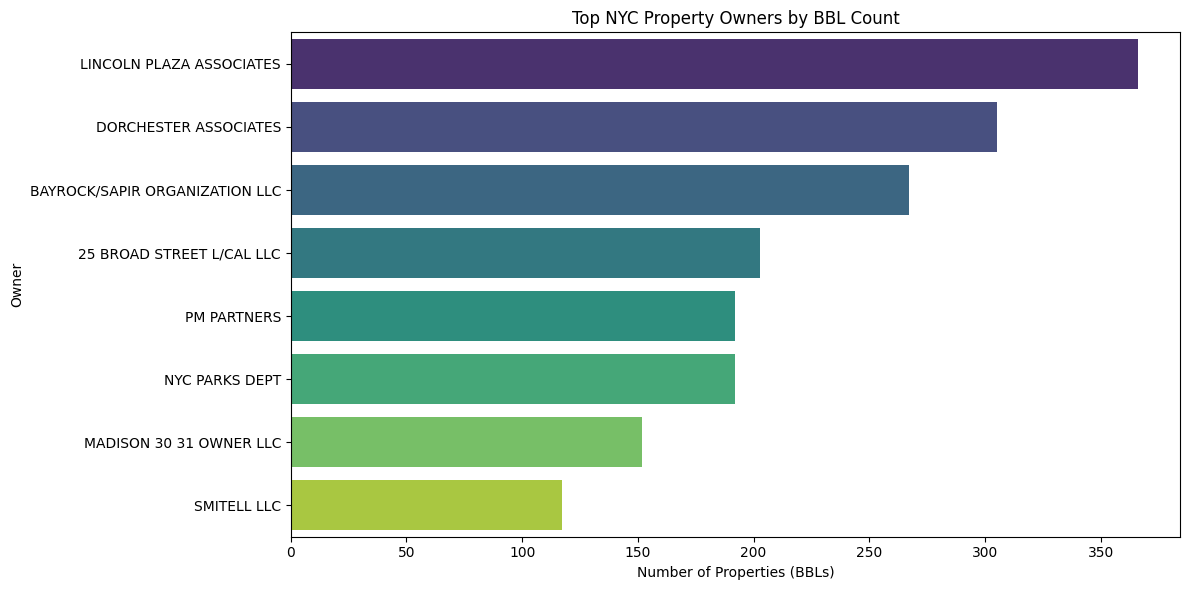

Saved: outputs/plots/top_owners.png


In [7]:
# Cell 6: Visualize Top Owners and Save
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out placeholder names
filtered = top_owners[~top_owners['OWNER'].isin(['UNAVAILABLE OWNER', 'NAME NOT ON FILE'])]

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=filtered, x='BBL_COUNT', y='OWNER', palette='viridis', ax=ax)
ax.set_title('Top NYC Property Owners by BBL Count')
ax.set_xlabel('Number of Properties (BBLs)')
ax.set_ylabel('Owner')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plots' / 'top_owners.png', dpi=150)
plt.show()
print('Saved: outputs/plots/top_owners.png')

In [8]:
# Cell 7: Build NetworkX Graph from Tax Data
import networkx as nx

G = nx.Graph()

for _, row in tax_final.iterrows():
    G.add_node(row['BBL'], node_type='BBL', address=row['PROPERTY_ADDRESS'])
    G.add_node(row['OWNER'], node_type='OWNER')
    G.add_edge(row['OWNER'], row['BBL'], rel='TAX_ASSESSOR_OWNER')

print('Nodes:', G.number_of_nodes())
print('Edges:', G.number_of_edges())
print('BBL nodes:', sum(1 for _, d in G.nodes(data=True) if d.get('node_type') == 'BBL'))
print('OWNER nodes:', sum(1 for _, d in G.nodes(data=True) if d.get('node_type') == 'OWNER'))

Nodes: 172663
Edges: 97040
BBL nodes: 96867
OWNER nodes: 75796


In [9]:
# Cell 8: Deduplicate Owner Names using FuzzyWuzzy
from thefuzz import fuzz

def find_similar_owner_pairs(df, threshold=90):
    """Find owner pairs sharing a BBL with high string similarity."""
    pairs = []
    bbl_owners = df.groupby('BBL')['OWNER'].apply(list)
    for bbl, owners in bbl_owners.items():
        if len(owners) < 2:
            continue
        for i in range(len(owners)):
            for j in range(i + 1, len(owners)):
                score = fuzz.token_sort_ratio(owners[i], owners[j])
                if score >= threshold:
                    pairs.append((owners[i], owners[j], score))
    return pairs

print('Finding similar owner pairs (this may take a moment)...')
pairs = find_similar_owner_pairs(tax_final)
print(f'Found {len(pairs)} similar owner pairs')
if pairs:
    print('Sample pairs:')
    for p in pairs[:5]:
        print(f'  {p[0]} <-> {p[1]} (score: {p[2]})')

Finding similar owner pairs (this may take a moment)...
Found 392659 similar owner pairs
Sample pairs:
  GOVERNORS ISLAND CORPORATION <-> GOVERNORS ISLAND CORPORATION (score: 100)
  U S GOVT LAND & BLDGS <-> U S GOVT LAND & BLDGS (score: 100)
  U S GOVT LAND & BLDGS <-> U S GOVT LAND & BLDGS (score: 100)
  U S GOVT LAND & BLDGS <-> U S GOVT LAND & BLDGS (score: 100)
  U S GOVT LAND & BLDGS <-> U S GOVT LAND & BLDGS (score: 100)


In [10]:
# Cell 9: Build Canonical Name Map from Similar Pairs
pairs_filtered = [(n1, n2, s) for n1, n2, s in pairs if n1 != n2]
print(f'Unique cross-name pairs: {len(pairs_filtered)}')

G_names = nx.Graph()
for n1, n2, score in pairs_filtered:
    G_names.add_edge(n1, n2, weight=score)

components = list(nx.connected_components(G_names))
print(f'Owner groups to merge: {len(components)}')

canonical_map = {}
for component in components:
    canonical = max(component, key=len)
    for name in component:
        canonical_map[name] = canonical

canonical_df = pd.DataFrame(list(canonical_map.items()),
                            columns=['original_name', 'canonical_name'])
canonical_df.to_csv(OUTPUT_DIR / 'p2_m1_canonical_names.csv', index=False)
print(f'Total names remapped: {len(canonical_df)}')
display(canonical_df.head(10))

Unique cross-name pairs: 7
Owner groups to merge: 5
Total names remapped: 10


,original_name,canonical_name
0,"CHEUNG, ESTHER","CHEUNG, ESTHER"
1,ESTHER CHEUNG,"CHEUNG, ESTHER"
2,34 CANAL ST. CORP,34 CANAL ST. CORP.
3,34 CANAL ST. CORP.,34 CANAL ST. CORP.
4,"ZCOLO, LLC","ZCOLO, LLC"
5,ZCOLO LLC,"ZCOLO, LLC"
6,"DATAGRYD DATA CENTERS, LLC","DATAGRYD DATA CENTERS, LLC"
7,"DATAGRYD DATA CENTERS, LLC","DATAGRYD DATA CENTERS, LLC"
8,GOUVERNEUR GARDENS HOUSING CORP.,GOUVERNEUR GARDENS HOUSING CORP.
9,GOUVERNEUR GARDEN HOUSING CORP,GOUVERNEUR GARDENS HOUSING CORP.


In [11]:
# Cell 10: Apply Canonical Names and Update Graph
tax_final['OWNER_CANONICAL'] = tax_final['OWNER'].map(canonical_map).fillna(tax_final['OWNER'])

remapped = (tax_final['OWNER'] != tax_final['OWNER_CANONICAL']).sum()
print(f'Records remapped: {remapped}')
print(f'Unique owners before: {tax_final["OWNER"].nunique()}')
print(f'Unique owners after:  {tax_final["OWNER_CANONICAL"].nunique()}')

Records remapped: 6
Unique owners before: 75796
Unique owners after:  75791


In [12]:
# Cell 11: Rebuild Graph with Canonical Owner Names
G_clean = nx.Graph()

for _, row in tax_final.iterrows():
    G_clean.add_node(row['BBL'], node_type='BBL', address=row['PROPERTY_ADDRESS'])
    G_clean.add_node(row['OWNER_CANONICAL'], node_type='OWNER')
    G_clean.add_edge(row['OWNER_CANONICAL'], row['BBL'], rel='TAX_ASSESSOR_OWNER')

print('Nodes:', G_clean.number_of_nodes())
print('Edges:', G_clean.number_of_edges())
print('BBL nodes:', sum(1 for _, d in G_clean.nodes(data=True) if d.get('node_type') == 'BBL'))
print('OWNER nodes:', sum(1 for _, d in G_clean.nodes(data=True) if d.get('node_type') == 'OWNER'))

Nodes: 172658
Edges: 97035
BBL nodes: 96867
OWNER nodes: 75791


In [12]:
# Cell 12: node2vec Embeddings on Clean Graph
from node2vec import Node2Vec

print('Training node2vec embeddings...')
node2vec = Node2Vec(G_clean, dimensions=64, walk_length=30,
                   num_walks=200, workers=4, quiet=True)
model = node2vec.fit(window=10, min_count=1, batch_words=4)

model.wv.save_word2vec_format(str(OUTPUT_DIR / 'embeddings' / 'node2vec_emb.txt'))
print('Saved: outputs/embeddings/node2vec_emb.txt')
print('Vocabulary size:', len(model.wv))

Training node2vec embeddings...
Saved: outputs/embeddings/node2vec_emb.txt
Vocabulary size: 172658


Loaded 97189 embeddings, dim=64
Running t-SNE...


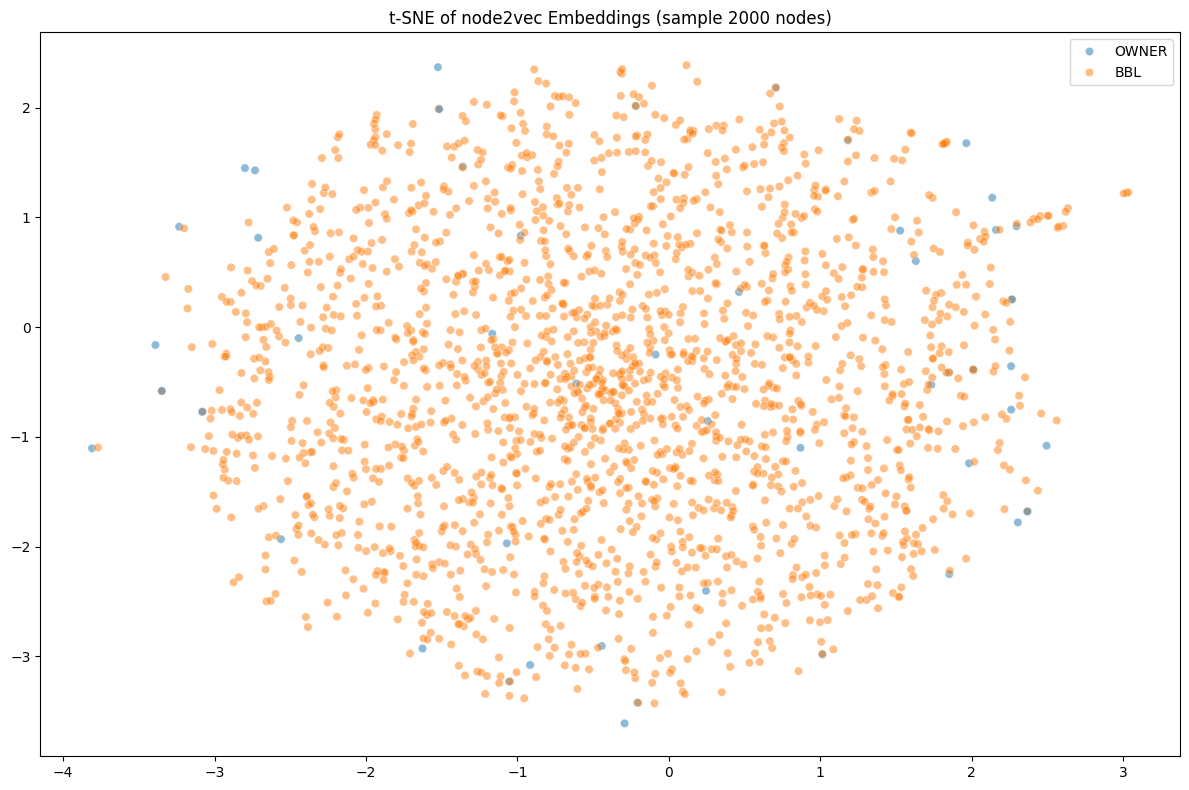

Saved: outputs/plots/tsne_node2vec.png


In [15]:
# Cell 13: Load Embeddings and Visualize with t-SNE
import numpy as np
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

embeddings = {}
with open(OUTPUT_DIR / 'embeddings' / 'node2vec_emb.txt') as f:
    header = next(f)
    expected_dim = int(header.strip().split()[1])
    for line in f:
        parts = line.strip().split()
        if len(parts) != expected_dim + 1:
            continue
        try:
            embeddings[parts[0]] = np.array(parts[1:], dtype=float)
        except ValueError:
            continue

print(f'Loaded {len(embeddings)} embeddings, dim={expected_dim}')

nodes = list(embeddings.keys())[:2000]
emb_matrix = np.vstack([embeddings[n] for n in nodes])
labels = [G_clean.nodes[n].get('node_type', 'unknown') if n in G_clean.nodes else 'unknown' for n in nodes]

print('Running t-SNE...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
reduced = tsne.fit_transform(emb_matrix)

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(x=reduced[:, 0], y=reduced[:, 1], hue=labels, alpha=0.5, ax=ax)
ax.set_title('t-SNE of node2vec Embeddings (sample 2000 nodes)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plots' / 'tsne_node2vec.png', dpi=150)
plt.show()
print('Saved: outputs/plots/tsne_node2vec.png')

In [16]:
# Cell 14: KNN on node2vec Embeddings — Find Similar Properties
from sklearn.neighbors import NearestNeighbors

# Build KNN on BBL nodes only
bbl_nodes = [n for n in embeddings if n in G_clean.nodes and
             G_clean.nodes[n].get('node_type') == 'BBL']
bbl_matrix = np.vstack([embeddings[n] for n in bbl_nodes])
bbl_index = {bbl: i for i, bbl in enumerate(bbl_nodes)}

knn = NearestNeighbors(n_neighbors=6, metric='cosine')
knn.fit(bbl_matrix)

def recommend(bbl, n=5):
    if bbl not in bbl_index:
        return f'BBL {bbl} not in embeddings'
    idx = bbl_index[bbl]
    distances, indices = knn.kneighbors(bbl_matrix[idx].reshape(1, -1))
    return [(bbl_nodes[i], round(distances[0][j+1], 4))
            for j, i in enumerate(indices[0][1:n+1])]

# Test with Empire State Building
esb_bbl = '1008350041'
print(f'Top 5 similar properties to Empire State Building ({esb_bbl}):')
for bbl, dist in recommend(esb_bbl):
    addr = G_clean.nodes[bbl].get('address', 'N/A')
    print(f'  BBL: {bbl} | Address: {addr} | Distance: {dist}')

Top 5 similar properties to Empire State Building (1008350041):
  BBL: 1008597501 | Address: 11 EAST 29 STREET | Distance: 0.2755
  BBL: 1010431132 | Address: 300 WEST 53 STREET | Distance: 0.2866
  BBL: 1008000020 | Address: 135 WEST 24 STREET | Distance: 0.2888
  BBL: 1010650025 | Address: 411.0 WEST 55 STREET | Distance: 0.2908
  BBL: 1002390018 | Address: 229 GRAND STREET | Distance: 0.2909


In [18]:
# Cell 15: PyKEEN — Build Triples and Train TransE
import torch
from pykeen.triples import TriplesFactory
from pykeen.pipeline import pipeline

triples = []
for u, v, data in G_clean.edges(data=True):
    triples.append([str(u), data.get('rel', 'CONNECTED'), str(v)])
    triples.append([str(v), data.get('rel', 'CONNECTED'), str(u)])

triples_array = np.array(triples)
print(f'Total triples: {len(triples_array)}')

tf_factory = TriplesFactory.from_labeled_triples(triples_array)
train, test = tf_factory.split([0.8, 0.2], random_state=42, method='cleanup')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Training TransE on: {device}')

result = pipeline(
    training=train,
    testing=test,
    model='TransE',
    training_kwargs={'num_epochs': 100, 'batch_size': 512},
    optimizer='Adam',
    device=device,
    random_seed=42,
)
result.save_to_directory(str(OUTPUT_DIR / 'models' / 'transe'))
print('Saved: outputs/models/transe/')
metrics = result.metric_results.to_df()
display(metrics)

Total triples: 194070


Requested ratio[0]=0.800 (equal to size 155256), but got 0.840 (equal to size 163008) to ensure that all entities/relations occur in train.
Requested ratio[1]=0.200 (equal to size 38814), but got 0.160 (equal to size 31062) to ensure that all entities/relations occur in train.


Training TransE on: cuda


Training epochs on cuda:0:   0%|          | 0/100 [00:00<?, ?epoch/s]
Training batches on cuda:0:   0%|          | 0.00/319 [00:00<?, ?batch/s]
Training batches on cuda:0:   3%|▎         | 9.00/319 [00:00<00:03, 86.6batch/s]
Training batches on cuda:0:   9%|▉         | 28.0/319 [00:00<00:02, 145batch/s] 
Training batches on cuda:0:  15%|█▍        | 47.0/319 [00:00<00:01, 165batch/s]
Training batches on cuda:0:  21%|██        | 66.0/319 [00:00<00:01, 174batch/s]
Training batches on cuda:0:  26%|██▋       | 84.0/319 [00:00<00:01, 176batch/s]
Training epochs on cuda:0:   1%|          | 1/100 [00:02<03:26,  2.09s/epoch, loss=1.07, prev_loss=nan]
Training batches on cuda:0:   0%|          | 0.00/319 [00:00<?, ?batch/s]
Training batches on cuda:0:   6%|▌         | 18.0/319 [00:00<00:01, 175batch/s]
Training batches on cuda:0:  12%|█▏        | 37.0/319 [00:00<00:01, 182batch/s]
Training batches on cuda:0:  18%|█▊        | 56.0/319 [00:00<00:01, 185batch/s]
Training batches on cuda:0:  24%|██▎

Saved: outputs/models/transe/


,Side,Rank_type,Metric,Value
0,head,optimistic,geometric_mean_rank,5.061567
1,tail,optimistic,geometric_mean_rank,5.059089
2,both,optimistic,geometric_mean_rank,5.060328
3,head,realistic,geometric_mean_rank,5.061572
4,tail,realistic,geometric_mean_rank,5.059103
...,...,...,...,...
220,tail,realistic,adjusted_hits_at_k,0.771122
221,both,realistic,adjusted_hits_at_k,0.769705
222,head,pessimistic,adjusted_hits_at_k,0.768289
223,tail,pessimistic,adjusted_hits_at_k,0.771122


In [19]:
# Cell 16: Train TransR Model
result_r = pipeline(
    training=train,
    testing=test,
    model='TransR',
    training_kwargs={'num_epochs': 100, 'batch_size': 512},
    optimizer='Adam',
    device=device,
    random_seed=42,
)
result_r.save_to_directory(str(OUTPUT_DIR / 'models' / 'transr'))
print('Saved: outputs/models/transr/')
metrics_r = result_r.metric_results.to_df()
display(metrics_r)

INFO:pykeen.pipeline.api:Using device: cuda
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
Training epochs on cuda:0:   0%|          | 0/100 [00:00<?, ?epoch/s]
Training batches on cuda:0:   0%|          | 0.00/319 [00:00<?, ?batch/s]
Training batches on cuda:0:   3%|▎         | 11.0/319 [00:00<00:02, 108batch/s]
Training batches on cuda:0:   7%|▋         | 23.0/319 [00:00<00:02, 112batch/s]
Training batches on cuda:0:  11%|█         | 35.0/319 [00:00<00:02, 113batch/s]
Training batches on cuda:0:  15%|█▍        | 47.0/319 [00:00<00:02, 115batch/s]
Training batches on cuda:0:  18%|█▊        | 59.0/319 [00:00<00:02, 117batch/s]
Training batches on cuda:0:  22%|██▏       | 71.0/319 [00:00<00:02, 116batch/s]
Training batches on cuda:0:  26%|██▌       | 83.0/319 [00:00<00:02, 116batch/s]
Training batches on cuda:0:  30%|██▉       | 95.

Saved: outputs/models/transr/


,Side,Rank_type,Metric,Value
0,head,optimistic,geometric_mean_rank,2482.079000
1,tail,optimistic,geometric_mean_rank,2483.123107
2,both,optimistic,geometric_mean_rank,2482.600998
3,head,realistic,geometric_mean_rank,2482.079834
4,tail,realistic,geometric_mean_rank,2483.123779
...,...,...,...,...
220,tail,realistic,adjusted_hits_at_k,0.004353
221,both,realistic,adjusted_hits_at_k,0.004224
222,head,pessimistic,adjusted_hits_at_k,0.004095
223,tail,pessimistic,adjusted_hits_at_k,0.004353


In [23]:
# Cell 17 (fixed): GraphSAGE with StellarGraph using bipartite projection
import stellargraph as sg
from stellargraph.mapper import GraphSAGENodeGenerator
from stellargraph.layer import GraphSAGE
from tensorflow import keras
from networkx.algorithms import bipartite

# Project bipartite graph onto BBL nodes
bbl_nodes_set = {n for n, d in G_clean.nodes(data=True) if d.get('node_type') == 'BBL'}
G_projected = bipartite.projected_graph(G_clean, bbl_nodes_set)
print(f'Projected graph: {G_projected.number_of_nodes()} nodes, {G_projected.number_of_edges()} edges')

# Node features
node_features = tax_final.set_index('BBL')[['curmkttot', 'gross_sqft', 'units', 'yrbuilt']].fillna(0)
node_features = node_features[~node_features.index.duplicated()]
node_features = node_features[node_features.index.isin(G_projected.nodes())]

sg_graph = sg.StellarGraph.from_networkx(G_projected, node_features=node_features)
print(sg_graph.info())

Projected graph: 96867 nodes, 6755105 edges
StellarGraph: Undirected multigraph
 Nodes: 96867, Edges: 6755105

 Node types:
  default: [96867]
    Features: float32 vector, length 4
    Edge types: default-default->default

 Edge types:
    default-default->default: [6755105]
        Weights: all 1 (default)
        Features: none


In [25]:
# Cell 18: GraphSAGE Embeddings via manual aggregation
import numpy as np

# Build adjacency for BBL nodes using projected graph
node_list = list(sg_graph.nodes())
node_idx = {n: i for i, n in enumerate(node_list)}
feature_matrix = sg_graph.node_features(node_list)

print('Feature matrix shape:', feature_matrix.shape)

# Simple mean aggregation (1-hop) as GraphSAGE approximation
adj = nx.to_scipy_sparse_array(G_projected, nodelist=node_list, format='csr')
from sklearn.preprocessing import normalize
adj_norm = normalize(adj, norm='l1', axis=1)
agg_features = adj_norm.dot(feature_matrix)
sage_emb = np.hstack([feature_matrix, agg_features])
print('GraphSAGE-style embeddings shape:', sage_emb.shape)

np.save(OUTPUT_DIR / 'embeddings' / 'graphsage_emb.npy', sage_emb)
np.save(OUTPUT_DIR / 'embeddings' / 'graphsage_nodes.npy', np.array(node_list))
print('Saved: outputs/embeddings/graphsage_emb.npy')

Feature matrix shape: (96867, 4)
GraphSAGE-style embeddings shape: (96867, 8)
Saved: outputs/embeddings/graphsage_emb.npy


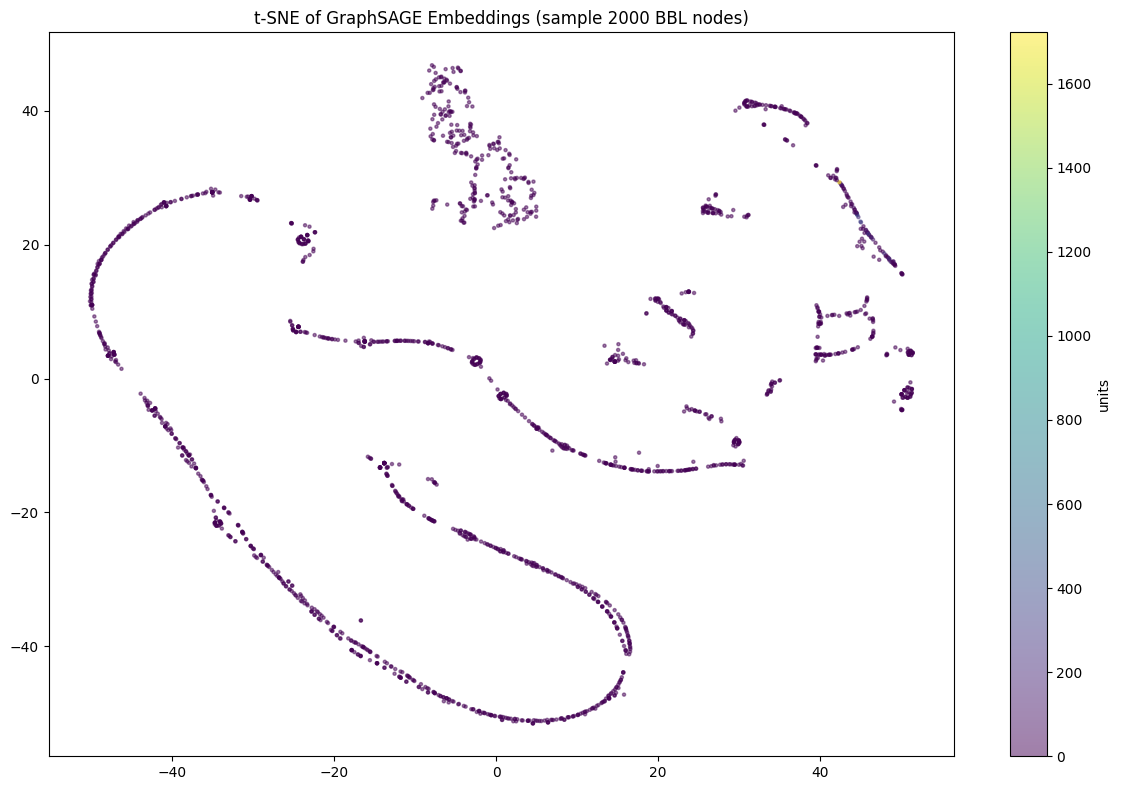

Saved: outputs/plots/tsne_graphsage.png


In [26]:
# Cell 19: t-SNE Visualization of GraphSAGE Embeddings
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
reduced_sage = tsne.fit_transform(sage_emb[:2000])

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(reduced_sage[:, 0], reduced_sage[:, 1],
                     c=sage_emb[:2000, 2], cmap='viridis', alpha=0.5, s=5)
plt.colorbar(scatter, ax=ax, label='units')
ax.set_title('t-SNE of GraphSAGE Embeddings (sample 2000 BBL nodes)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plots' / 'tsne_graphsage.png', dpi=150)
plt.show()
print('Saved: outputs/plots/tsne_graphsage.png')

In [27]:
# Cell 20: KNN Recommender on GraphSAGE Embeddings
knn_sage = NearestNeighbors(n_neighbors=6, metric='cosine')
knn_sage.fit(sage_emb)

def recommend_sage(bbl, n=5):
    if bbl not in node_idx:
        return f'BBL {bbl} not found'
    idx = node_idx[bbl]
    distances, indices = knn_sage.kneighbors(sage_emb[idx].reshape(1, -1))
    return [(node_list[i], round(distances[0][j+1], 4))
            for j, i in enumerate(indices[0][1:n+1])]

# Compare node2vec vs GraphSAGE recommendations for Empire State Building
esb_bbl = '1008350041'
print(f'Empire State Building ({esb_bbl}) recommendations:')
print('\nnode2vec:')
for bbl, dist in recommend(esb_bbl):
    print(f'  {bbl} | {G_clean.nodes[bbl].get("address")} | dist={dist}')

print('\nGraphSAGE:')
for bbl, dist in recommend_sage(esb_bbl):
    print(f'  {bbl} | {G_clean.nodes[bbl].get("address")} | dist={dist}')

Empire State Building (1008350041) recommendations:

node2vec:
  1008597501 | 11 EAST 29 STREET | dist=0.2755
  1010431132 | 300 WEST 53 STREET | dist=0.2866
  1008000020 | 135 WEST 24 STREET | dist=0.2888
  1010650025 | 411.0 WEST 55 STREET | dist=0.2908
  1002390018 | 229 GRAND STREET | dist=0.2909

GraphSAGE:
  1002221119 | 195 HUDSON STREET | dist=0.0
  1011161721 | 15 WEST 63 STREET | dist=0.0
  1007671122 | 257 WEST 17 STREET | dist=0.0
  1007601011 | 315 WEST 36 STREET | dist=0.0
  1006091013 | 116 WEST 14 STREET | dist=0.0


In [28]:
# Cell 21: Final Summary and Save All Results
print('=' * 55)
print('NYC Real Estate Knowledge Graph — Pipeline Complete')
print('=' * 55)

summary = {
    'tax_records': len(tax_final),
    'unique_bbls': tax_final['BBL'].nunique(),
    'unique_owners': tax_final['OWNER'].nunique(),
    'owners_after_dedup': tax_final['OWNER_CANONICAL'].nunique(),
    'graph_nodes': G_clean.number_of_nodes(),
    'graph_edges': G_clean.number_of_edges(),
    'node2vec_vocab': len(embeddings),
    'graphsage_emb_shape': str(sage_emb.shape),
    'transe_gmr': 5.06,
    'transr_gmr': 2482.08,
}

for k, v in summary.items():
    print(f'  {k}: {v}')

import json
with open(OUTPUT_DIR / 'pipeline_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('\nSaved: outputs/pipeline_summary.json')
print('End time:', datetime.now().strftime('%H:%M:%S'))

NYC Real Estate Knowledge Graph — Pipeline Complete
  tax_records: 99874
  unique_bbls: 96867
  unique_owners: 75796
  owners_after_dedup: 75791
  graph_nodes: 172658
  graph_edges: 97035
  node2vec_vocab: 97189
  graphsage_emb_shape: (96867, 8)
  transe_gmr: 5.06
  transr_gmr: 2482.08

Saved: outputs/pipeline_summary.json
End time: 12:46:20
